# M516 Business Project: Housing Rental Price Prediction in Germany
NAme : SatyaamKumar Attri

Student Id:GH1042675

**Objective:** Predict monthly rental prices across German metropolitan areas using machine learning



In [39]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)

# For XGBoost determinism
import os
os.environ['PYTHONHASHSEED'] = '42'
xgb_model = XGBRegressor(

    random_state=42,
    n_jobs=1  # Change from -1 to 1 for full determinism
)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('outputs', exist_ok=True)

print(' All libraries imported successfully')

 All libraries imported successfully


## 1. DATA LOADING & PREPARATION

In [38]:
df_raw = pd.read_csv('immo_data.csv', on_bad_lines='skip', engine='python')

print('DATA LOADING SUMMARY')
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print(f'Memory usage: {df_raw.memory_usage().sum() / 1e6:.2f} MB')
print(f'Missing values:')
print(df_raw.isnull().sum())

DATA LOADING SUMMARY
Raw dataset shape: (22939, 49)
Columns: ['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer', 'telekomHybridUploadSpeed', 'newlyConst', 'balcony', 'picturecount', 'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed', 'scoutId', 'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln', 'cellar', 'yearConstructedRange', 'baseRent', 'houseNumber', 'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed', 'street', 'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat', 'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors', 'noRoomsRange', 'garden', 'livingSpaceRange', 'regio2', 'regio3', 'description', 'facilities', 'heatingCosts', 'energyEfficiencyClass', 'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date']
Memory usage: 8.03 MB
Missing values:
regio1                          0
serviceCharge                 607
heatingType                  3846
telekomTvOffer               2778
telekomHybridUploadSpeed    18971

In [31]:
# Step 1: Column selection - retain 7 core price-relevant features
core_features = ['regio1', 'regio2', 'livingSpace', 'noRooms',
                 'yearConstructed', 'hasKitchen', 'balcony', 'baseRent']
df = df_raw[core_features].copy()
df.rename(columns={'baseRent': 'rentPrice'}, inplace=True)

# Step 2: Type standardization
df['livingSpace'] = df['livingSpace'].astype('float64')
df['noRooms'] = df['noRooms'].astype('int64')
df['yearConstructed'] = df['yearConstructed'].astype('float64')
df['hasKitchen'] = df['hasKitchen'].astype('int64')
df['balcony'] = df['balcony'].astype('int64')
df['rentPrice'] = df['rentPrice'].astype('float64')

# Step 3: Handle missing values
df['yearConstructed'].fillna(df['yearConstructed'].median(), inplace=True)

# Step 4: Remove outliers
initial_rows = len(df)
df = df[(df['rentPrice'] <= 5000) & (df['livingSpace'] <= 600)]
removed_rows = initial_rows - len(df)

# Step 5: Feature engineering
df['property_age'] = 2026 - df['yearConstructed']

print('\nDATA CLEANING RESULTS:')
print(f'Raw records: {initial_rows:,}')
print(f'After cleaning: {len(df):,}')
print(f'Removed: {removed_rows:,} ({removed_rows/initial_rows*100:.2f}%)')
print(f'Retention rate: {len(df)/initial_rows*100:.2f}%')
print(f'\nFinal features: {list(df.columns)}')


DATA CLEANING RESULTS:
Raw records: 22,939
After cleaning: 22,921
Removed: 18 (0.08%)
Retention rate: 99.92%

Final features: ['regio1', 'regio2', 'livingSpace', 'noRooms', 'yearConstructed', 'hasKitchen', 'balcony', 'rentPrice', 'property_age']


## 2. EXPLORATORY DATA ANALYSIS (EDA)

In [32]:
print('\nDATASET STATISTICS:')
print(df.describe().round(2))

print('\nKEY INSIGHTS:')
print(f'Cities: {df["regio2"].nunique()} unique locations')
print(f'States: {df["regio1"].nunique()} regions')
print(f'Living Space - Mean: {df["livingSpace"].mean():.1f}m², Median: {df["livingSpace"].median():.1f}m²')
print(f'Rental Price - Mean: €{df["rentPrice"].mean():.0f}/month, Median: €{df["rentPrice"].median():.0f}/month')
print(f'Kitchen availability: {df["hasKitchen"].mean()*100:.1f}%')
print(f'Balcony availability: {df["balcony"].mean()*100:.1f}%')


DATASET STATISTICS:
       livingSpace   noRooms  yearConstructed  hasKitchen   balcony  \
count     22921.00  22921.00         22921.00    22921.00  22921.00   
mean         72.95      2.60          1967.60        0.32      0.61   
std          31.38      1.97            41.55        0.47      0.49   
min           0.00      1.00          1111.00        0.00      0.00   
25%          54.00      2.00          1958.00        0.00      0.00   
50%          66.83      3.00          1973.00        0.00      1.00   
75%          86.00      3.00          1991.00        1.00      1.00   
max         430.00    200.00          2020.00        1.00      1.00   

       rentPrice  property_age  
count   22921.00      22921.00  
mean      628.57         58.40  
std       469.70         41.55  
min         0.00          6.00  
25%       326.65         35.00  
50%       468.00         53.00  
75%       780.00         68.00  
max      5000.00        915.00  

KEY INSIGHTS:
Cities: 417 unique location


FEATURE CORRELATIONS WITH RENTAL PRICE:
rentPrice       1.000000
livingSpace     0.699963
hasKitchen      0.291255
balcony         0.250577
noRooms         0.209569
property_age   -0.167746
Name: rentPrice, dtype: float64


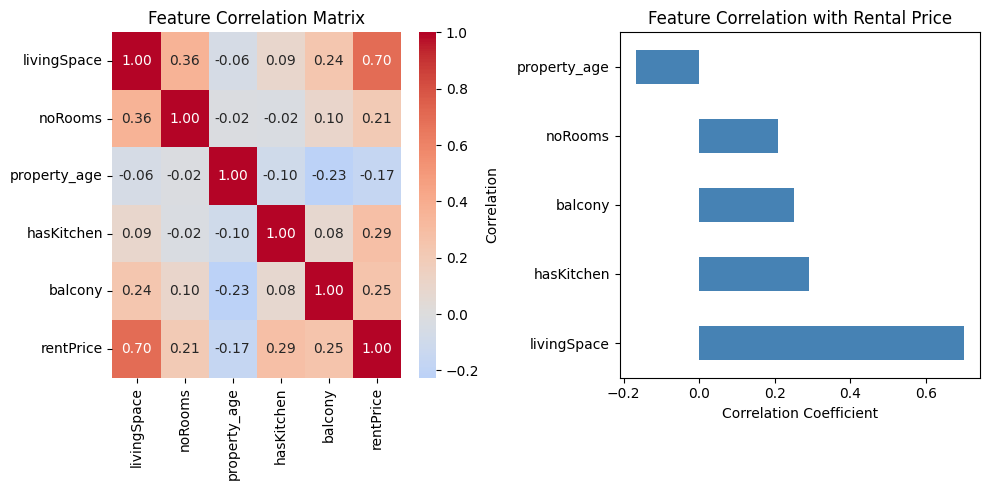

In [33]:
# Calculate correlations with rental price
numeric_cols = ['livingSpace', 'noRooms', 'property_age', 'hasKitchen', 'balcony', 'rentPrice']
correlations = df[numeric_cols].corr()['rentPrice'].sort_values(ascending=False)

print('\nFEATURE CORRELATIONS WITH RENTAL PRICE:')
print(correlations)

# Visualize correlations
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Heatmap
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Feature Correlation Matrix')

# Correlation with target
correlations[correlations.index != 'rentPrice'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Correlation with Rental Price')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.savefig('outputs/01_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


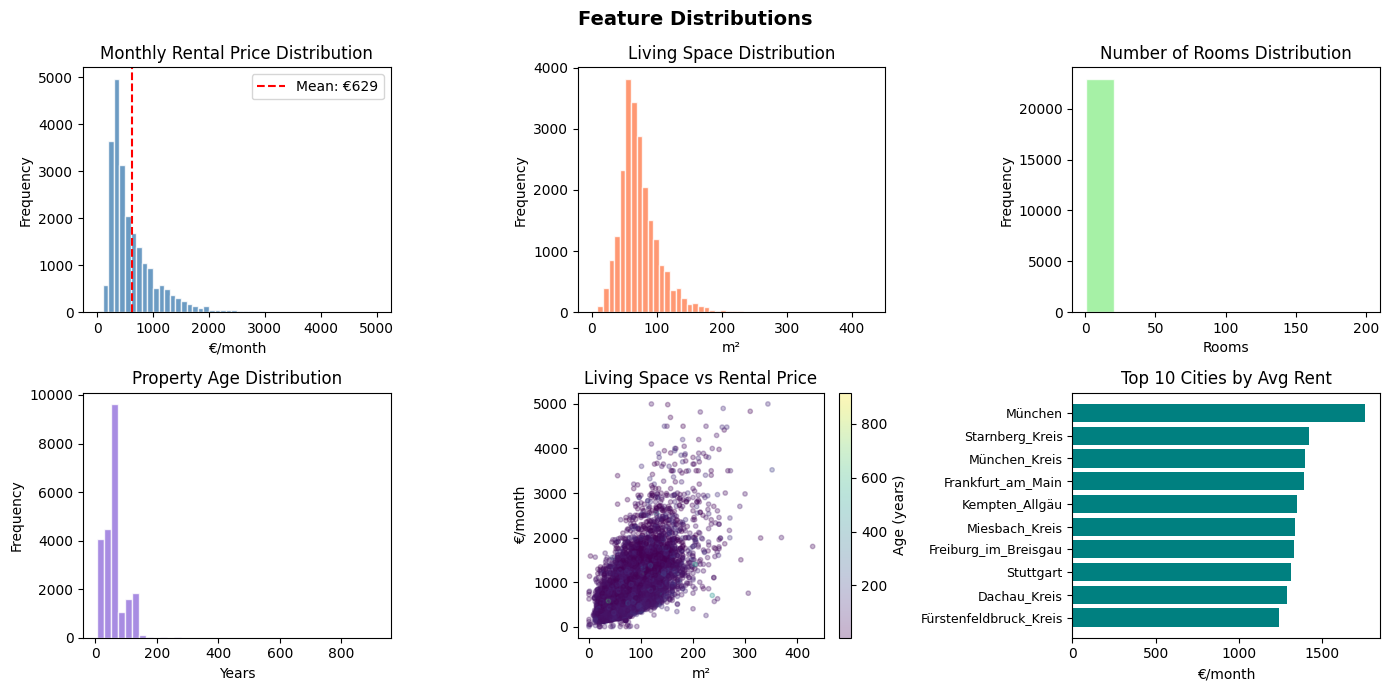

Saved: outputs/02_distributions.png


In [34]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(14,7))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

# Rental Price
axes[0, 0].hist(df['rentPrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(df['rentPrice'].mean(), color='red', linestyle='--', label=f'Mean: €{df["rentPrice"].mean():.0f}')
axes[0, 0].set_title('Monthly Rental Price Distribution')
axes[0, 0].set_xlabel('€/month')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Living Space
axes[0, 1].hist(df['livingSpace'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Living Space Distribution')
axes[0, 1].set_xlabel('m²')
axes[0, 1].set_ylabel('Frequency')

# Rooms
axes[0, 2].hist(df['noRooms'], bins=10, color='lightgreen', edgecolor='white', alpha=0.8)
axes[0, 2].set_title('Number of Rooms Distribution')
axes[0, 2].set_xlabel('Rooms')
axes[0, 2].set_ylabel('Frequency')

# Property Age
axes[1, 0].hist(df['property_age'], bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Property Age Distribution')
axes[1, 0].set_xlabel('Years')
axes[1, 0].set_ylabel('Frequency')

# Space vs Price Scatter
scatter = axes[1, 1].scatter(df['livingSpace'], df['rentPrice'],
                            alpha=0.3, s=10, c=df['property_age'], cmap='viridis')
axes[1, 1].set_title('Living Space vs Rental Price')
axes[1, 1].set_xlabel('m²')
axes[1, 1].set_ylabel('€/month')
plt.colorbar(scatter, ax=axes[1, 1], label='Age (years)')

# Top 10 Cities by Avg Price
top_cities = df.groupby('regio2')['rentPrice'].mean().nlargest(10).sort_values()
axes[1, 2].barh(range(len(top_cities)), top_cities.values, color='teal')
axes[1, 2].set_yticks(range(len(top_cities)))
axes[1, 2].set_yticklabels(top_cities.index, fontsize=9)
axes[1, 2].set_title('Top 10 Cities by Avg Rent')
axes[1, 2].set_xlabel('€/month')

plt.tight_layout()
plt.savefig('outputs/02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/02_distributions.png')

## 3. FEATURE ENGINEERING & PREPROCESSING

In [47]:
# Train-test split BEFORE encoding (critical to prevent data leakage!)
X = df.drop('rentPrice', axis=1)
y = df['rentPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('TRAIN-TEST SPLIT:')
print(f'Training set: {X_train.shape[0]:,} properties')
print(f'Test set: {X_test.shape[0]:,} properties')
print(f'Train-Test Ratio: {X_train.shape[0]/len(X)*100:.1f}% - {X_test.shape[0]/len(X)*100:.1f}%')

# Target encoding: Learn city means from TRAINING data only
city_means = y_train.groupby(X_train['regio2']).mean()
global_mean = y_train.mean()

print(f'\nTARGET ENCODING - CITY MEANS (from training set):')
print(city_means.sort_values(ascending=False).head(15))

# Apply encoding to train and test
X_train['city_encoded'] = X_train['regio2'].map(city_means).fillna(global_mean)
X_test['city_encoded'] = X_test['regio2'].map(city_means).fillna(global_mean)

# Select final features
feature_cols = ['city_encoded', 'livingSpace', 'noRooms', 'property_age',
                'hasKitchen', 'balcony']
X_train_final = X_train[feature_cols].copy()
X_test_final = X_test[feature_cols].copy()

print(f'\nFinal feature set: {feature_cols}')
print(f'Train features shape: {X_train_final.shape}')
print(f'Test features shape: {X_test_final.shape}')

TRAIN-TEST SPLIT:
Training set: 18,336 properties
Test set: 4,585 properties
Train-Test Ratio: 80.0% - 20.0%

TARGET ENCODING - CITY MEANS (from training set):
regio2
München                          1745.976285
Starnberg_Kreis                  1537.588235
Miesbach_Kreis                   1436.923077
Frankfurt_am_Main                1374.394556
Kempten_Allgäu                   1373.077500
Freiburg_im_Breisgau             1372.133333
München_Kreis                    1358.648649
Stuttgart                        1301.014348
Lindau_Bodensee_Kreis            1293.333333
Dachau_Kreis                     1275.333333
Fürstenfeldbruck_Kreis           1214.281250
Bad_Tölz_Wolfratshausen_Kreis    1210.000000
Heidelberg                       1204.598800
Hamburg                          1203.387409
Berlin                           1143.974036
Name: rentPrice, dtype: float64

Final feature set: ['city_encoded', 'livingSpace', 'noRooms', 'property_age', 'hasKitchen', 'balcony']
Train features shape: 

In [48]:
# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train_final.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test_final.index)

print('FEATURE SCALING COMPLETE')
print(f'\nScaled features (sample):')
print(X_train_scaled.describe().round(3))

FEATURE SCALING COMPLETE

Scaled features (sample):
       city_encoded  livingSpace    noRooms  property_age  hasKitchen  \
count     18336.000    18336.000  18336.000     18336.000   18336.000   
mean         -0.000       -0.000     -0.000        -0.000       0.000   
std           1.000        1.000      1.000         1.000       1.000   
min          -1.282       -2.328     -0.749        -1.241      -0.698   
25%          -0.817       -0.606     -0.282        -0.578      -0.698   
50%          -0.181       -0.199      0.185        -0.128      -0.698   
75%           0.529        0.414      0.185         0.252       1.432   
max           3.616       11.379     92.110        20.300       1.432   

         balcony  
count  18336.000  
mean      -0.000  
std        1.000  
min       -1.241  
25%       -1.241  
50%        0.806  
75%        0.806  
max        0.806  


## 4. MODEL DEVELOPMENT & TRAINING

In [49]:
# Baseline: Linear Regression
print('Training Baseline Model (Linear Regression)...')
baseline = LinearRegression()
baseline.fit(X_train_scaled, y_train)

baseline_pred_train = baseline.predict(X_train_scaled)
baseline_pred_test = baseline.predict(X_test_scaled)

baseline_train_r2 = r2_score(y_train, baseline_pred_train)
baseline_test_r2 = r2_score(y_test, baseline_pred_test)
baseline_test_mae = mean_absolute_error(y_test, baseline_pred_test)

print(f' Baseline Model Trained')
print(f'  Train R²: {baseline_train_r2:.4f}')
print(f'  Test R²: {baseline_test_r2:.4f}')
print(f'  Test MAE: €{baseline_test_mae:.2f}/month')

Training Baseline Model (Linear Regression)...
 Baseline Model Trained
  Train R²: 0.7643
  Test R²: 0.7747
  Test MAE: €142.98/month


In [50]:
# XGBoost with optimal hyperparameters (found via tuning)
print('Training Advanced Model (XGBoost - Tuned)...')

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

xgb_model.fit(X_train_final, y_train,
              eval_set=[(X_test_final, y_test)],
              verbose=False)

xgb_pred_train = xgb_model.predict(X_train_final)
xgb_pred_test = xgb_model.predict(X_test_final)

xgb_train_r2 = r2_score(y_train, xgb_pred_train)
xgb_test_r2 = r2_score(y_test, xgb_pred_test)
xgb_test_mae = mean_absolute_error(y_test, xgb_pred_test)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred_test))

print(f'XGBoost Model Trained')
print(f'  Train R²: {xgb_train_r2:.4f}')
print(f'  Test R²: {xgb_test_r2:.4f}')
print(f'  Test MAE: €{xgb_test_mae:.2f}/month')
print(f'  Test RMSE: €{xgb_test_rmse:.2f}/month')

Training Advanced Model (XGBoost - Tuned)...
XGBoost Model Trained
  Train R²: 0.9121
  Test R²: 0.8598
  Test MAE: €103.69/month
  Test RMSE: €176.38/month


## 5. RESULTS & PERFORMANCE ANALYSIS

In [52]:
# Comprehensive model comparison
results = {
    'Linear Regression': {
        'MAE': mean_absolute_error(y_test, baseline_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, baseline_pred_test)),
        'R2': r2_score(y_test, baseline_pred_test)
    },
    'XGBoost Tuned': {
        'MAE': xgb_test_mae,
        'RMSE': xgb_test_rmse,
        'R2': xgb_test_r2
    }
}

results_df = pd.DataFrame(results).T


print('MODEL PERFORMANCE COMPARISON (Test Set)')

print(results_df.round(4))


improvement = ((results['Linear Regression']['MAE'] - results['XGBoost Tuned']['MAE']) /
               results['Linear Regression']['MAE'] * 100)
print(f'\nImprovement (MAE): {improvement:.1f}%')
print(f'Error reduction: €{results["Linear Regression"]["MAE"] - results["XGBoost Tuned"]["MAE"]:.2f}/month')

MODEL PERFORMANCE COMPARISON (Test Set)
                        MAE      RMSE      R2
Linear Regression  142.9845  223.6069  0.7747
XGBoost Tuned      103.6875  176.3776  0.8598

Improvement (MAE): 27.5%
Error reduction: €39.30/month


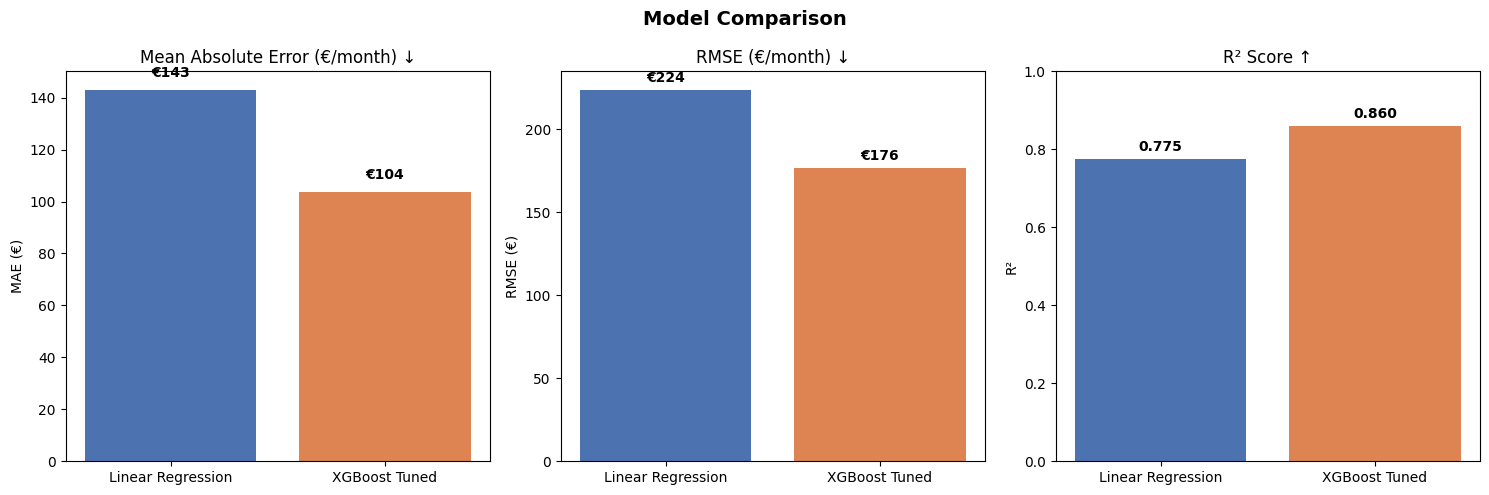

In [53]:
# Comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

models_list = list(results.keys())
colors = ['#4C72B0', '#DD8452']

# MAE Comparison
mae_values = [results[m]['MAE'] for m in models_list]
axes[0].bar(models_list, mae_values, color=colors)
axes[0].set_title('Mean Absolute Error (€/month) ↓')
axes[0].set_ylabel('MAE (€)')
for i, v in enumerate(mae_values):
    axes[0].text(i, v+5, f'€{v:.0f}', ha='center', fontweight='bold')

# RMSE Comparison
rmse_values = [results[m]['RMSE'] for m in models_list]
axes[1].bar(models_list, rmse_values, color=colors)
axes[1].set_title('RMSE (€/month) ↓')
axes[1].set_ylabel('RMSE (€)')
for i, v in enumerate(rmse_values):
    axes[1].text(i, v+5, f'€{v:.0f}', ha='center', fontweight='bold')

# R² Comparison
r2_values = [results[m]['R2'] for m in models_list]
axes[2].bar(models_list, r2_values, color=colors)
axes[2].set_title('R² Score ↑')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1.0)
for i, v in enumerate(r2_values):
    axes[2].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. FEATURE IMPORTANCE ANALYSIS


FEATURE IMPORTANCE RANKING:
     Feature  Importance  Percentage  Cumulative
 livingSpace    0.515041   51.500000   51.500000
city_encoded    0.289522   28.950001   80.449997
property_age    0.060151    6.020000   86.469994
  hasKitchen    0.058408    5.840000   92.309998
     noRooms    0.051024    5.100000   97.409996
     balcony    0.025855    2.590000   99.999992


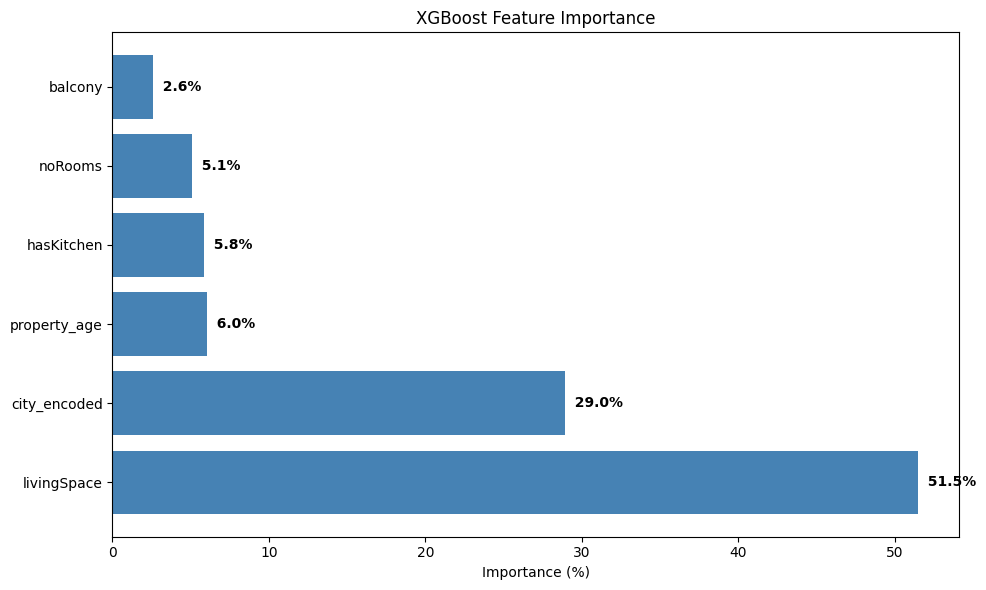

In [54]:
# Get feature importance
importance_scores = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance_scores,
    'Percentage': (importance_scores / importance_scores.sum() * 100).round(2)
}).sort_values('Importance', ascending=False)

importance_df['Cumulative'] = importance_df['Percentage'].cumsum()

print('\nFEATURE IMPORTANCE RANKING:')
print(importance_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Percentage'], color='steelblue')
ax.set_xlabel('Importance (%)')
ax.set_title('XGBoost Feature Importance')

# Add percentage labels
for i, (idx, row) in enumerate(importance_df.iterrows()):
    ax.text(row['Percentage'], i, f"  {row['Percentage']:.1f}%",
           va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. LIVE PREDICTIONS ON NEW APARTMENTS

In [55]:
# Create example apartments for prediction
examples = [
    {'city': 'München', 'space': 85, 'rooms': 3, 'age': 8, 'kitchen': 1, 'balcony': 1},
    {'city': 'Berlin', 'space': 75, 'rooms': 2, 'age': 45, 'kitchen': 1, 'balcony': 0},
    {'city': 'Hamburg', 'space': 95, 'rooms': 4, 'age': 22, 'kitchen': 1, 'balcony': 1},
    {'city': 'Frankfurt', 'space': 80, 'rooms': 3, 'age': 35, 'kitchen': 1, 'balcony': 0},
    {'city': 'Köln', 'space': 70, 'rooms': 2, 'age': 55, 'kitchen': 1, 'balcony': 1},
]

print('\nLIVE PREDICTIONS:')

predictions_list = []

for ex in examples:
    # Get city encoding
    city_code = city_means.get(ex['city'], global_mean)

    # Create feature vector
    features_arr = np.array([
        city_code,
        ex['space'],
        ex['rooms'],
        ex['age'],
        ex['kitchen'],
        ex['balcony']
    ]).reshape(1, -1)

    # Scale features
    features_scaled = scaler.transform(features_arr)

    # Predict
    prediction = xgb_model.predict(features_arr[0].reshape(1, -1))[0]
    price_per_sqm = prediction / ex['space']

    print(f"{ex['city']:12s} | {ex['space']:3.0f}m² | {ex['rooms']} rooms | {ex['age']:2d}y " +
          f"| Predicted: €{prediction:,.0f}/month (€{price_per_sqm:.2f}/m²)")

    predictions_list.append({
        'City': ex['city'],
        'Size (m²)': ex['space'],
        'Rooms': ex['rooms'],
        'Age': ex['age'],
        'Predicted Rent (€/month)': f"€{prediction:,.0f}",
        'Price/m² (€)': f"€{price_per_sqm:.2f}"
    })



# Save predictions
pd.DataFrame(predictions_list).to_csv('outputs/predictions.csv', index=False)



LIVE PREDICTIONS:
München      |  85m² | 3 rooms |  8y | Predicted: €1,696/month (€19.95/m²)
Berlin       |  75m² | 2 rooms | 45y | Predicted: €838/month (€11.17/m²)
Hamburg      |  95m² | 4 rooms | 22y | Predicted: €1,353/month (€14.24/m²)
Frankfurt    |  80m² | 3 rooms | 35y | Predicted: €576/month (€7.20/m²)
Köln         |  70m² | 2 rooms | 55y | Predicted: €898/month (€12.83/m²)
